In [ ]:
from google.colab import drive

In [ ]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!mv /content/drive/MyDrive/CIFAR-10 /content/CIFAR-10

mv: cannot stat '/content/drive/MyDrive/CIFAR-10': No such file or directory


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation, Add, BatchNormalization, Input, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

In [ ]:
datagen = ImageDataGenerator(rescale=1./255)
train_generator = datagen.flow_from_directory("/content/drive/MyDrive/projects/neural networks/CIFAR-10-images-master/CIFAR-10-images-master/train", target_size=(32,32),
                                              batch_size=32,
                                              class_mode="categorical")

test_generator = datagen.flow_from_directory('/content/drive/MyDrive/projects/neural networks/CIFAR-10-images-master/CIFAR-10-images-master/test',
                                             target_size=(32, 32),
                                             batch_size=32,
                                             class_mode="categorical")

Found 50000 images belonging to 10 classes.
Found 10000 images belonging to 10 classes.


In [ ]:
print(train_generator.class_indices)

{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


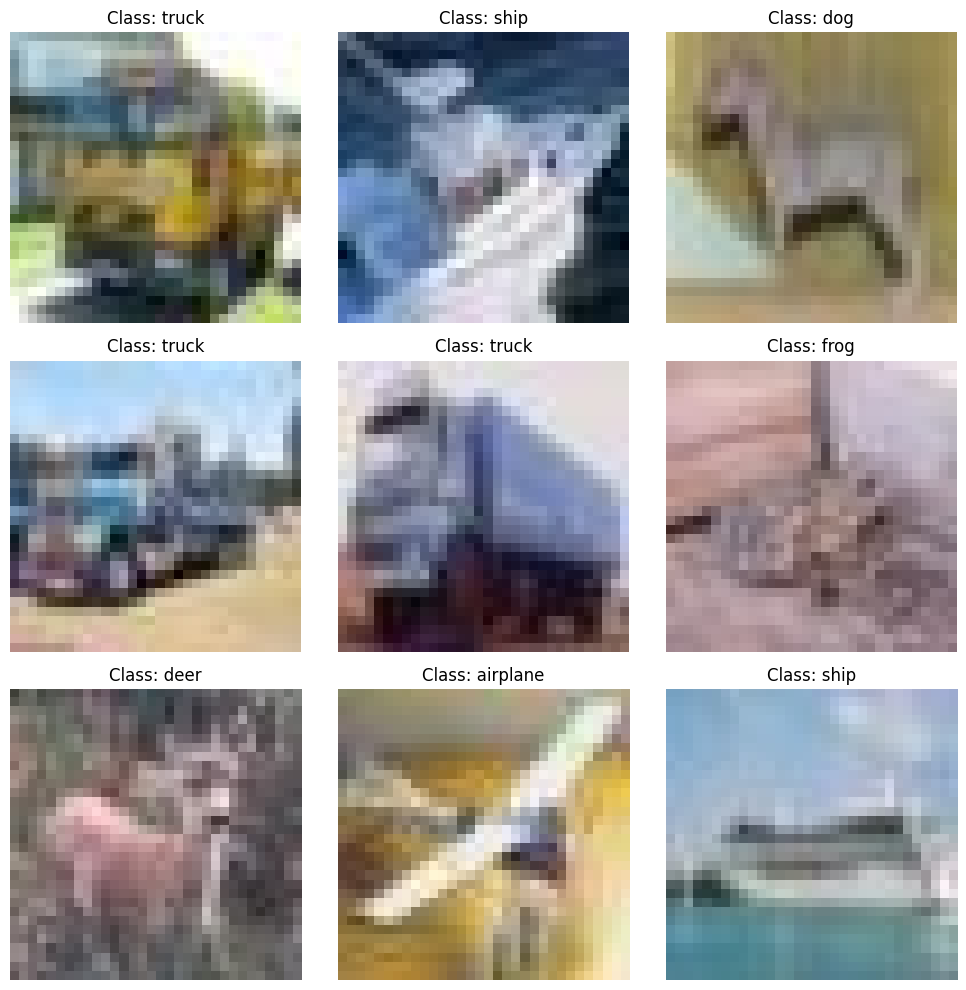

In [ ]:
images, labels = next(train_generator)
class_names = list(train_generator.class_indices.keys())
plt.figure(figsize=(10, 10))
for i in range(9):
    label_index = labels[i].argmax()
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Class: {class_names[label_index]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
input_tensor = Input(shape=(32, 32,3))
base_model = MobileNetV2(input_tensor=input_tensor,
                         include_top=False,
                         weights=None)

x = base_model.output
x = GlobalAveragePooling2D()(x)
output_tensor = Dense(10, activation="softmax")(x)

model = Model(inputs=input_tensor, outputs=output_tensor)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
checkpoint = ModelCheckpoint("mobilenet_best.h5", monitor='val_loss', save_best_only=True)

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.fit(train_generator,
          epochs=20,
          validation_data=test_generator,
          callbacks=[early_stop, checkpoint])

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.4634 - loss: 1.5296

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 271s 147ms/step - accuracy: 0.4634 - loss: 1.5296 - val_accuracy: 0.4270 - val_loss: 3.7609
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 200s 128ms/step - accuracy: 0.5142 - loss: 1.3634 - val_accuracy: 0.2419 - val_loss: 4.8130
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.4976 - loss: 1.4259

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 202s 129ms/step - accuracy: 0.4976 - loss: 1.4258 - val_accuracy: 0.4754 - val_loss: 2.9101
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.5818 - loss: 1.1963

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 206s 132ms/step - accuracy: 0.5818 - loss: 1.1963 - val_accuracy: 0.4710 - val_loss: 2.8526
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 206s 132ms/step - accuracy: 0.6073 - loss: 1.0990 - val_accuracy: 0.3870 - val_loss: 3.7855
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.6258 - loss: 1.0584

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 205s 131ms/step - accuracy: 0.6258 - loss: 1.0584 - val_accuracy: 0.5605 - val_loss: 1.7571
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 197s 126ms/step - accuracy: 0.6550 - loss: 0.9844 - val_accuracy: 0.5605 - val_loss: 1.9980
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 197s 126ms/step - accuracy: 0.6785 - loss: 0.9200 - val_accuracy: 0.5423 - val_loss: 1.8769
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.6926 - loss: 0.8834

...

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 202s 129ms/step - accuracy: 0.7248 - loss: 0.7813 - val_accuracy: 0.6660 - val_loss: 1.1278
Epoch 12/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.7421 - loss: 0.7416

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 201s 128ms/step - accuracy: 0.7421 - loss: 0.7416 - val_accuracy: 0.6815 - val_loss: 1.0137
Epoch 13/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 198s 127ms/step - accuracy: 0.7609 - loss: 0.6944 - val_accuracy: 0.6678 - val_loss: 1.1530
Epoch 14/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 197s 126ms/step - accuracy: 0.7652 - loss: 0.6659 - val_accuracy: 0.6560 - val_loss: 1.0967
Epoch 15/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 196s 125ms/step - accuracy: 0.7737 - loss: 0.6576 - val_accuracy: 0.6396 - val_loss: 1.2082
Epoch 16/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 200s 124ms/step - accuracy: 0.7853 - loss: 0.6179 - val_accuracy: 0.6773 - val_loss: 1.0584
Epoch 17/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.7936 - loss: 0.5909

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 196s 125ms/step - accuracy: 0.7936 - loss: 0.5909 - val_accuracy: 0.7032 - val_loss: 1.0129
Epoch 18/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 195s 125ms/step - accuracy: 0.8008 - loss: 0.5734 - val_accuracy: 0.5927 - val_loss: 1.3791
Epoch 19/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.7985 - loss: 0.5743

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 190s 122ms/step - accuracy: 0.7985 - loss: 0.5743 - val_accuracy: 0.6975 - val_loss: 0.9739
Epoch 20/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8175 - loss: 0.5249

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 186s 119ms/step - accuracy: 0.8175 - loss: 0.5249 - val_accuracy: 0.7299 - val_loss: 0.8523
